# Uvoz podataka i podela

In [10]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA dostupna:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Uredjaj: CPU")


PyTorch: 2.11.0+cu128
CUDA dostupna: True
GPU: Tesla T4


In [ ]:
import sys
from pathlib import Path

import torch
import torch.nn as nn

from torchvision.datasets import EuroSAT
from torchvision import transforms
from torch.utils.data import Subset, DataLoader


project_path = Path.cwd()
if project_path.name == "notebooks":
    project_path = project_path.parent

print(
    "ResNet fajl postoji:",
    (project_path / "src" / "models" / "resnet.py").exists()
)

sys.path.insert(0, str(project_path))

from src.models.resnet import ResNet18
from src.models.densenet import DenseNet121
from src.models.dpn import DPN
from src.models.vit import VisionTransformer


data_path = project_path / "data" / "raw"
split_path = project_path / "splits"

data_path.mkdir(parents=True, exist_ok=True)
(project_path / "results" / "checkpoints").mkdir(
    parents=True,
    exist_ok=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Projekat:", project_path)
print("Podaci:", data_path)
print("Podele:", split_path)
print("Uredjaj:", device)

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    basic_transform
])

dataset = EuroSAT(
    root=data_path,
    download=True
)

name_u_index = {}

for index, (image_path, label) in enumerate(dataset.samples):
    image_name = Path(image_path).name
    name_u_index[image_name] = index


def read_indexi(file_name):
    indices = []

    with open(split_path / file_name, "r") as file:
        for line in file:
            image_name = Path(line.strip()).name
            indices.append(name_u_index[image_name])

    return indices


train_indexi = read_indexi("eurosat-train.txt")
val_indexi = read_indexi("eurosat-val.txt")
test_indexi = read_indexi("eurosat-test.txt")

print("Trening:", len(train_indexi))
print("Val:", len(val_indexi))
print("Test:", len(test_indexi))

train_dataset = EuroSAT(
    root=data_path,
    transform=train_transform
)

eval_dataset = EuroSAT(
    root=data_path,
    transform=basic_transform
)

train_data = Subset(train_dataset, train_indexi)
val_data = Subset(eval_dataset, val_indexi)
test_data = Subset(eval_dataset, test_indexi)

print("Trening:", len(train_data))
print("Validacija:", len(val_data))
print("Test:", len(test_data)) # opet provera


ResNet fajl postoji: True
Projekat: /content/DPN_EuroSAT
Podaci: /content/DPN_EuroSAT/data/raw
Podele: /content/DPN_EuroSAT/splits
Uredjaj: cuda


100%|██████████| 94.3M/94.3M [00:01<00:00, 72.1MB/s]


Trening: 16200
Val: 5400
Test: 5400
Trening: 16200
Validacija: 5400
Test: 5400


# DataLoader

In [16]:
batch_size = 64

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

print("Trening batchevi:", len(train_loader))
print("Validacioni batchevi:", len(val_loader))
print("Test batcevi:", len(test_loader))

Trening batchevi: 254
Validacioni batchevi: 85
Test batcevi: 85


# Treniranje modela (ResNet18)

In [17]:
torch.manual_seed(42)

model = ResNet18().to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
best_val_accuracy = 0

resnet_train_accuracy = []
resnet_val_accuracy = []

for epoch in range(epochs):

    model.train()
    train_correct = 0

    for batch_number, (images, labels) in enumerate(train_loader, start=1):

        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct = train_correct + (predictions == labels).sum().item()

        if batch_number % 25 == 0:
            print(
                f"Epoha {epoch + 1}, "
                f"batch {batch_number}/{len(train_loader)}"
            )

    train_accuracy = 100 * train_correct / len(train_data)


    model.eval()
    val_correct = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            val_correct = val_correct + (predictions == labels).sum().item()

    val_accuracy = 100 * val_correct / len(val_data)

    resnet_train_accuracy.append(train_accuracy)
    resnet_val_accuracy.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            project_path / "results" / "checkpoints" / "resnet18.pth"
        )

    print(
        f"Epoha {epoch + 1}/{epochs} - "
        f"trening: {train_accuracy:.2f}% - "
        f"validacija: {val_accuracy:.2f}%"
    )

print("Najbolja validaciona tacnost:", best_val_accuracy)

Epoha 1, batch 25/254
Epoha 1, batch 50/254
Epoha 1, batch 75/254
Epoha 1, batch 100/254
Epoha 1, batch 125/254
Epoha 1, batch 150/254
Epoha 1, batch 175/254
Epoha 1, batch 200/254
Epoha 1, batch 225/254
Epoha 1, batch 250/254
Epoha 1/10 - trening: 64.62% - validacija: 60.11%
Epoha 2, batch 25/254
Epoha 2, batch 50/254
Epoha 2, batch 75/254
Epoha 2, batch 100/254
Epoha 2, batch 125/254
Epoha 2, batch 150/254
Epoha 2, batch 175/254
Epoha 2, batch 200/254
Epoha 2, batch 225/254
Epoha 2, batch 250/254
Epoha 2/10 - trening: 75.22% - validacija: 52.33%
Epoha 3, batch 25/254
Epoha 3, batch 50/254
Epoha 3, batch 75/254
Epoha 3, batch 100/254
Epoha 3, batch 125/254
Epoha 3, batch 150/254
Epoha 3, batch 175/254
Epoha 3, batch 200/254
Epoha 3, batch 225/254
Epoha 3, batch 250/254
Epoha 3/10 - trening: 79.86% - validacija: 67.15%
Epoha 4, batch 25/254
Epoha 4, batch 50/254
Epoha 4, batch 75/254
Epoha 4, batch 100/254
Epoha 4, batch 125/254
Epoha 4, batch 150/254
Epoha 4, batch 175/254
Epoha 4, ba

# Preuzimanje rezultata sa Google Colab

In [ ]:
import json


checkpoint_path = (
    project_path / "results" / "checkpoints" / "resnet18.pth"
)

metrics_path = project_path / "results" / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)

device_name = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

resnet_results = {
    "model": "ResNet18",
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "train_accuracy": resnet_train_accuracy,
    "val_accuracy": resnet_val_accuracy,
    "best_epoch": resnet_val_accuracy.index(
        max(resnet_val_accuracy)
    ) + 1,
    "best_val_accuracy": best_val_accuracy,
    "device": device_name
}

with open(
    metrics_path / "resnet18.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(resnet_results, file, indent=4)

print("Checkpoint postoji:", checkpoint_path.exists())
print(
    "Velicina checkpointa:",
    round(checkpoint_path.stat().st_size / 1024**2, 2),
    "MB"
)


Checkpoint postoji: True
Velicina checkpointa: 42.7 MB


In [ ]:
checkpoint_path = (
    project_path / "results" / "checkpoints" / "resnet18.pth"
)

model = ResNet18().to(device)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

model.eval()
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_correct += (predictions == labels).sum().item()


resnet_test_accuracy = 100 * test_correct / len(test_data)

print(f"ResNet test tacnost: {resnet_test_accuracy:.2f}%")

ResNet test tacnost: 87.56%


In [ ]:
import json


metrics_file = (
    project_path / "results" / "metrics" / "resnet18.json"
)

with open(metrics_file, "r", encoding="utf-8") as file:
    resnet_results = json.load(file)

resnet_results["test_accuracy"] = resnet_test_accuracy

with open(metrics_file, "w", encoding="utf-8") as file:
    json.dump(resnet_results, file, indent=4)

print("Sacuvana test tacnost:", resnet_test_accuracy)


Sacuvana test tacnost: 87.55555555555556


# Treniranje modela(DenseNet121)

In [ ]:
torch.manual_seed(42)

model = DenseNet121().to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10
best_val_accuracy = 0

densenet_train_accuracy = []
densenet_val_accuracy = []

for epoch in range(epochs):

    model.train()
    train_correct = 0

    for batch_number, (images, labels) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        if batch_number % 25 == 0:

            print(
                f"Epoha {epoch + 1}, "
                f"batch {batch_number}/{len(train_loader)}"
            )

    train_accuracy = (
        100 * train_correct / len(train_data)
    )


    model.eval()
    val_correct = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_accuracy = (
        100 * val_correct / len(val_data)
    )

    densenet_train_accuracy.append(train_accuracy)
    densenet_val_accuracy.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            project_path
            / "results"
            / "checkpoints"
            / "densenet121.pth"
        )

    print(
        f"Epoha {epoch + 1}/{epochs} - "
        f"trening: {train_accuracy:.2f}% - "
        f"validacija: {val_accuracy:.2f}%"
    )

print(
    "Najbolja validaciona tacnost:",
    best_val_accuracy
)

Epoha 1, batch 25/254
Epoha 1, batch 50/254
Epoha 1, batch 75/254
Epoha 1, batch 100/254
Epoha 1, batch 125/254
Epoha 1, batch 150/254
Epoha 1, batch 175/254
Epoha 1, batch 200/254
Epoha 1, batch 225/254
Epoha 1, batch 250/254
Epoha 1/10 - trening: 66.17% - validacija: 71.04%
Epoha 2, batch 25/254
Epoha 2, batch 50/254
Epoha 2, batch 75/254
Epoha 2, batch 100/254
Epoha 2, batch 125/254
Epoha 2, batch 150/254
Epoha 2, batch 175/254
Epoha 2, batch 200/254
Epoha 2, batch 225/254
Epoha 2, batch 250/254
Epoha 2/10 - trening: 77.22% - validacija: 63.04%
Epoha 3, batch 25/254
Epoha 3, batch 50/254
Epoha 3, batch 75/254
Epoha 3, batch 100/254
Epoha 3, batch 125/254
Epoha 3, batch 150/254
Epoha 3, batch 175/254
Epoha 3, batch 200/254
Epoha 3, batch 225/254
Epoha 3, batch 250/254
Epoha 3/10 - trening: 82.20% - validacija: 64.20%
Epoha 4, batch 25/254
Epoha 4, batch 50/254
Epoha 4, batch 75/254
Epoha 4, batch 100/254
Epoha 4, batch 125/254
Epoha 4, batch 150/254
Epoha 4, batch 175/254
Epoha 4, ba

# Preuzimanje rezultata DenseNet-a sa Google Colab

In [ ]:
import json
checkpoint_path = (
    project_path
    / "results"
    / "checkpoints"
    / "densenet121.pth"
)

model = DenseNet121().to(device)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

model.eval()
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == labels
        ).sum().item()


densenet_test_accuracy = (
    100 * test_correct / len(test_data)
)

print(
    f"DenseNet test tacnost: "
    f"{densenet_test_accuracy:.2f}%"
)


metrics_path = project_path / "results" / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)

metrics_file = metrics_path / "densenet121.json"

densenet_results = {
    "model": "DenseNet121",
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "train_accuracy": densenet_train_accuracy,
    "val_accuracy": densenet_val_accuracy,
    "best_epoch": densenet_val_accuracy.index(
        max(densenet_val_accuracy)
    ) + 1,
    "best_val_accuracy": best_val_accuracy,
    "test_accuracy": densenet_test_accuracy,
    "device": device_name
}

with open(metrics_file, "w", encoding="utf-8") as file:
    json.dump(densenet_results, file, indent=4)



print("Checkpoint postoji:", checkpoint_path.exists())
print(
    "Velicina checkpointa:",
    round(checkpoint_path.stat().st_size / 1024**2, 2),
    "MB"
)


DenseNet test tacnost: 91.81%
Checkpoint postoji: True
Velicina checkpointa: 27.09 MB


# Treniranje modela(DPN)

In [ ]:
torch.manual_seed(42)

model = DPN().to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10
best_val_accuracy = 0

dpn_train_accuracy = []
dpn_val_accuracy = []

for epoch in range(epochs):

    model.train()
    train_correct = 0

    for batch_number, (images, labels) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        if batch_number % 25 == 0:

            print(
                f"Epoha {epoch + 1}, "
                f"batch {batch_number}/{len(train_loader)}"
            )

    train_accuracy = (
        100 * train_correct / len(train_data)
    )


    model.eval()
    val_correct = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_accuracy = (
        100 * val_correct / len(val_data)
    )

    dpn_train_accuracy.append(train_accuracy)
    dpn_val_accuracy.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            project_path
            / "results"
            / "checkpoints"
            / "dpn.pth"
        )

    print(
        f"Epoha {epoch + 1}/{epochs} - "
        f"trening: {train_accuracy:.2f}% - "
        f"validacija: {val_accuracy:.2f}%"
    )

print(
    "Najbolja validaciona tacnost:",
    best_val_accuracy
)

Epoha 1, batch 25/254
Epoha 1, batch 50/254
Epoha 1, batch 75/254
Epoha 1, batch 100/254
Epoha 1, batch 125/254
Epoha 1, batch 150/254
Epoha 1, batch 175/254
Epoha 1, batch 200/254
Epoha 1, batch 225/254
Epoha 1, batch 250/254
Epoha 1/10 - trening: 61.97% - validacija: 71.04%
Epoha 2, batch 25/254
Epoha 2, batch 50/254
Epoha 2, batch 75/254
Epoha 2, batch 100/254
Epoha 2, batch 125/254
Epoha 2, batch 150/254
Epoha 2, batch 175/254
Epoha 2, batch 200/254
Epoha 2, batch 225/254
Epoha 2, batch 250/254
Epoha 2/10 - trening: 73.43% - validacija: 68.72%
Epoha 3, batch 25/254
Epoha 3, batch 50/254
Epoha 3, batch 75/254
Epoha 3, batch 100/254
Epoha 3, batch 125/254
Epoha 3, batch 150/254
Epoha 3, batch 175/254
Epoha 3, batch 200/254
Epoha 3, batch 225/254
Epoha 3, batch 250/254
Epoha 3/10 - trening: 79.08% - validacija: 60.52%
Epoha 4, batch 25/254
Epoha 4, batch 50/254
Epoha 4, batch 75/254
Epoha 4, batch 100/254
Epoha 4, batch 125/254
Epoha 4, batch 150/254
Epoha 4, batch 175/254
Epoha 4, ba

# Preuzimanje rezultata DPN-a sa Google Colab

In [ ]:
import json
checkpoint_path = (
    project_path
    / "results"
    / "checkpoints"
    / "dpn.pth"
)

model = DPN().to(device)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

model.eval()
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == labels
        ).sum().item()


dpn_test_accuracy = (
    100 * test_correct / len(test_data)
)

print(
    f"DPN test tacnost: "
    f"{dpn_test_accuracy:.2f}%"
)


metrics_path = project_path / "results" / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)

metrics_file = metrics_path / "dpn.json"

dpn_results = {
    "model": "DPN",
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "train_accuracy": dpn_train_accuracy,
    "val_accuracy": dpn_val_accuracy,
    "best_epoch": dpn_val_accuracy.index(
        max(dpn_val_accuracy)
    ) + 1,
    "best_val_accuracy": best_val_accuracy,
    "test_accuracy": dpn_test_accuracy,
    "device": device_name
}

with open(metrics_file, "w", encoding="utf-8") as file:
    json.dump(dpn_results, file, indent=4)



print("Checkpoint postoji:", checkpoint_path.exists())
print(
    "Velicina checkpointa:",
    round(checkpoint_path.stat().st_size / 1024**2, 2),
    "MB"
)


DPN test tacnost: 91.67%
Checkpoint postoji: True
Velicina checkpointa: 37.4 MB


# Treniranje modela(ViT)

In [ ]:
torch.manual_seed(42)

model = VisionTransformer().to(device)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10
best_val_accuracy = 0

vit_train_accuracy = []
vit_val_accuracy = []

for epoch in range(epochs):

    model.train()
    train_correct = 0

    for batch_number, (images, labels) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        if batch_number % 25 == 0:

            print(
                f"Epoha {epoch + 1}, "
                f"batch {batch_number}/{len(train_loader)}"
            )

    train_accuracy = (
        100 * train_correct / len(train_data)
    )


    model.eval()
    val_correct = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

    val_accuracy = (
        100 * val_correct / len(val_data)
    )

    vit_train_accuracy.append(train_accuracy)
    vit_val_accuracy.append(val_accuracy)

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            project_path
            / "results"
            / "checkpoints"
            / "vit.pth"
        )

    print(
        f"Epoha {epoch + 1}/{epochs} - "
        f"trening: {train_accuracy:.2f}% - "
        f"validacija: {val_accuracy:.2f}%"
    )

print(
    "Najbolja validaciona tacnost:",
    best_val_accuracy
)

Epoha 1, batch 25/254
Epoha 1, batch 50/254
Epoha 1, batch 75/254
Epoha 1, batch 100/254
Epoha 1, batch 125/254
Epoha 1, batch 150/254
Epoha 1, batch 175/254
Epoha 1, batch 200/254
Epoha 1, batch 225/254
Epoha 1, batch 250/254
Epoha 1/10 - trening: 55.99% - validacija: 71.44%
Epoha 2, batch 25/254
Epoha 2, batch 50/254
Epoha 2, batch 75/254
Epoha 2, batch 100/254
Epoha 2, batch 125/254
Epoha 2, batch 150/254
Epoha 2, batch 175/254
Epoha 2, batch 200/254
Epoha 2, batch 225/254
Epoha 2, batch 250/254
Epoha 2/10 - trening: 71.02% - validacija: 75.93%
Epoha 3, batch 25/254
Epoha 3, batch 50/254
Epoha 3, batch 75/254
Epoha 3, batch 100/254
Epoha 3, batch 125/254
Epoha 3, batch 150/254
Epoha 3, batch 175/254
Epoha 3, batch 200/254
Epoha 3, batch 225/254
Epoha 3, batch 250/254
Epoha 3/10 - trening: 77.36% - validacija: 77.70%
Epoha 4, batch 25/254
Epoha 4, batch 50/254
Epoha 4, batch 75/254
Epoha 4, batch 100/254
Epoha 4, batch 125/254
Epoha 4, batch 150/254
Epoha 4, batch 175/254
Epoha 4, ba

# Preuzimanje rezultata ViT-a sa Google Colab

In [ ]:
import json
checkpoint_path = (
    project_path
    / "results"
    / "checkpoints"
    / "vit.pth"
)

model = VisionTransformer().to(device)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True
    )
)

model.eval()
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == labels
        ).sum().item()


vit_test_accuracy = (
    100 * test_correct / len(test_data)
)

print(
    f"ViT test tacnost: "
    f"{vit_test_accuracy:.2f}%"
)


metrics_path = project_path / "results" / "metrics"
metrics_path.mkdir(parents=True, exist_ok=True)

metrics_file = metrics_path / "vit.json"

vit_results = {
    "model": "VisionTransformer",
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "train_accuracy": vit_train_accuracy,
    "val_accuracy": vit_val_accuracy,
    "best_epoch": vit_val_accuracy.index(
        max(vit_val_accuracy)
    ) + 1,
    "best_val_accuracy": best_val_accuracy,
    "test_accuracy": vit_test_accuracy,
    "device": device_name
}

with open(metrics_file, "w", encoding="utf-8") as file:
    json.dump(vit_results, file, indent=4)



print("Checkpoint postoji:", checkpoint_path.exists())
print(
    "Velicina checkpointa:",
    round(checkpoint_path.stat().st_size / 1024**2, 2),
    "MB"
)


ViT test tacnost: 86.37%
Checkpoint postoji: True
Velicina checkpointa: 1.15 MB


# Prikaz postignute tacnosti kroz epohe treniranja za sva 4 modela

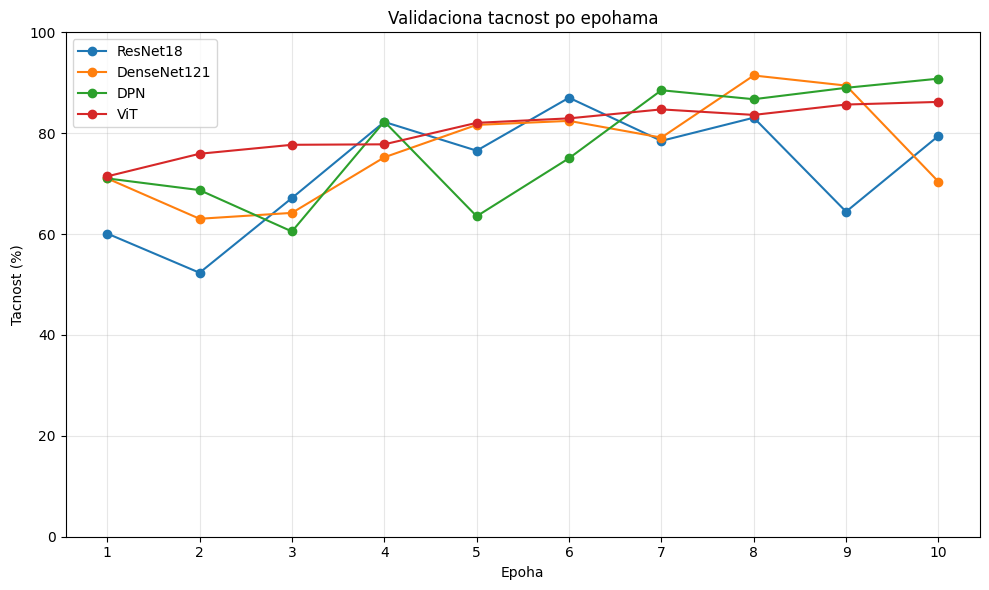

In [ ]:
import matplotlib.pyplot as plt


figures_path = project_path / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

epoch_numbers = range(1, 11)

plt.figure(figsize=(10, 6))

plt.plot(
    epoch_numbers,
    resnet_val_accuracy,
    marker="o",
    label="ResNet18"
)

plt.plot(
    epoch_numbers,
    densenet_val_accuracy,
    marker="o",
    label="DenseNet121"
)

plt.plot(
    epoch_numbers,
    dpn_val_accuracy,
    marker="o",
    label="DPN"
)

plt.plot(
    epoch_numbers,
    vit_val_accuracy,
    marker="o",
    label="ViT"
)

plt.title("Validaciona tacnost po epohama")
plt.xlabel("Epoha")
plt.ylabel("Tacnost (%)")
plt.xticks(epoch_numbers)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    figures_path / "validation_accuracy.png",
    dpi=200
)

plt.show()

# Poredjenje test tacnosti

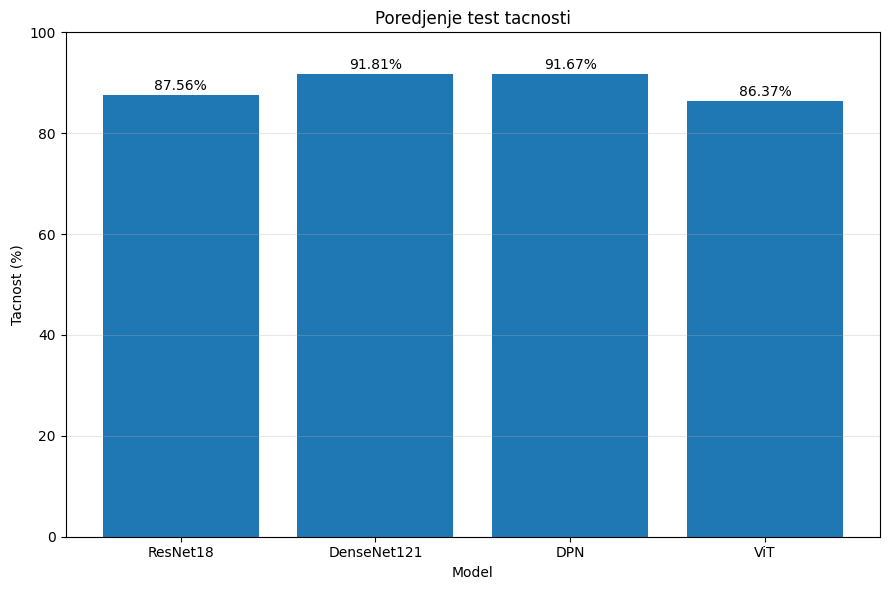

In [ ]:
model_names = [
    "ResNet18",
    "DenseNet121",
    "DPN",
    "ViT"
]

test_tacnosti = [
    resnet_test_accuracy,
    densenet_test_accuracy,
    dpn_test_accuracy,
    vit_test_accuracy
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    model_names,
    test_tacnosti
)

for bar, accuracy in zip(bars, test_tacnosti):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.title("Poredjenje test tacnosti")
plt.xlabel("Model")
plt.ylabel("Tacnost (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    figures_path / "test_accuracy.png",
    dpi=200
)

plt.show()

# Matrica konfuzije za sva 4 modela

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


def get_predictions(model, checkpoint_name):

    checkpoint_path = (
        project_path
        / "results"
        / "checkpoints"
        / checkpoint_name
    )

    model = model.to(device)

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True
        )
    )

    model.eval()

    true_labels = []
    predicted_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            true_labels.extend(labels.tolist())
            predicted_labels.extend(
                predictions.cpu().tolist()
            )

    return true_labels, predicted_labels

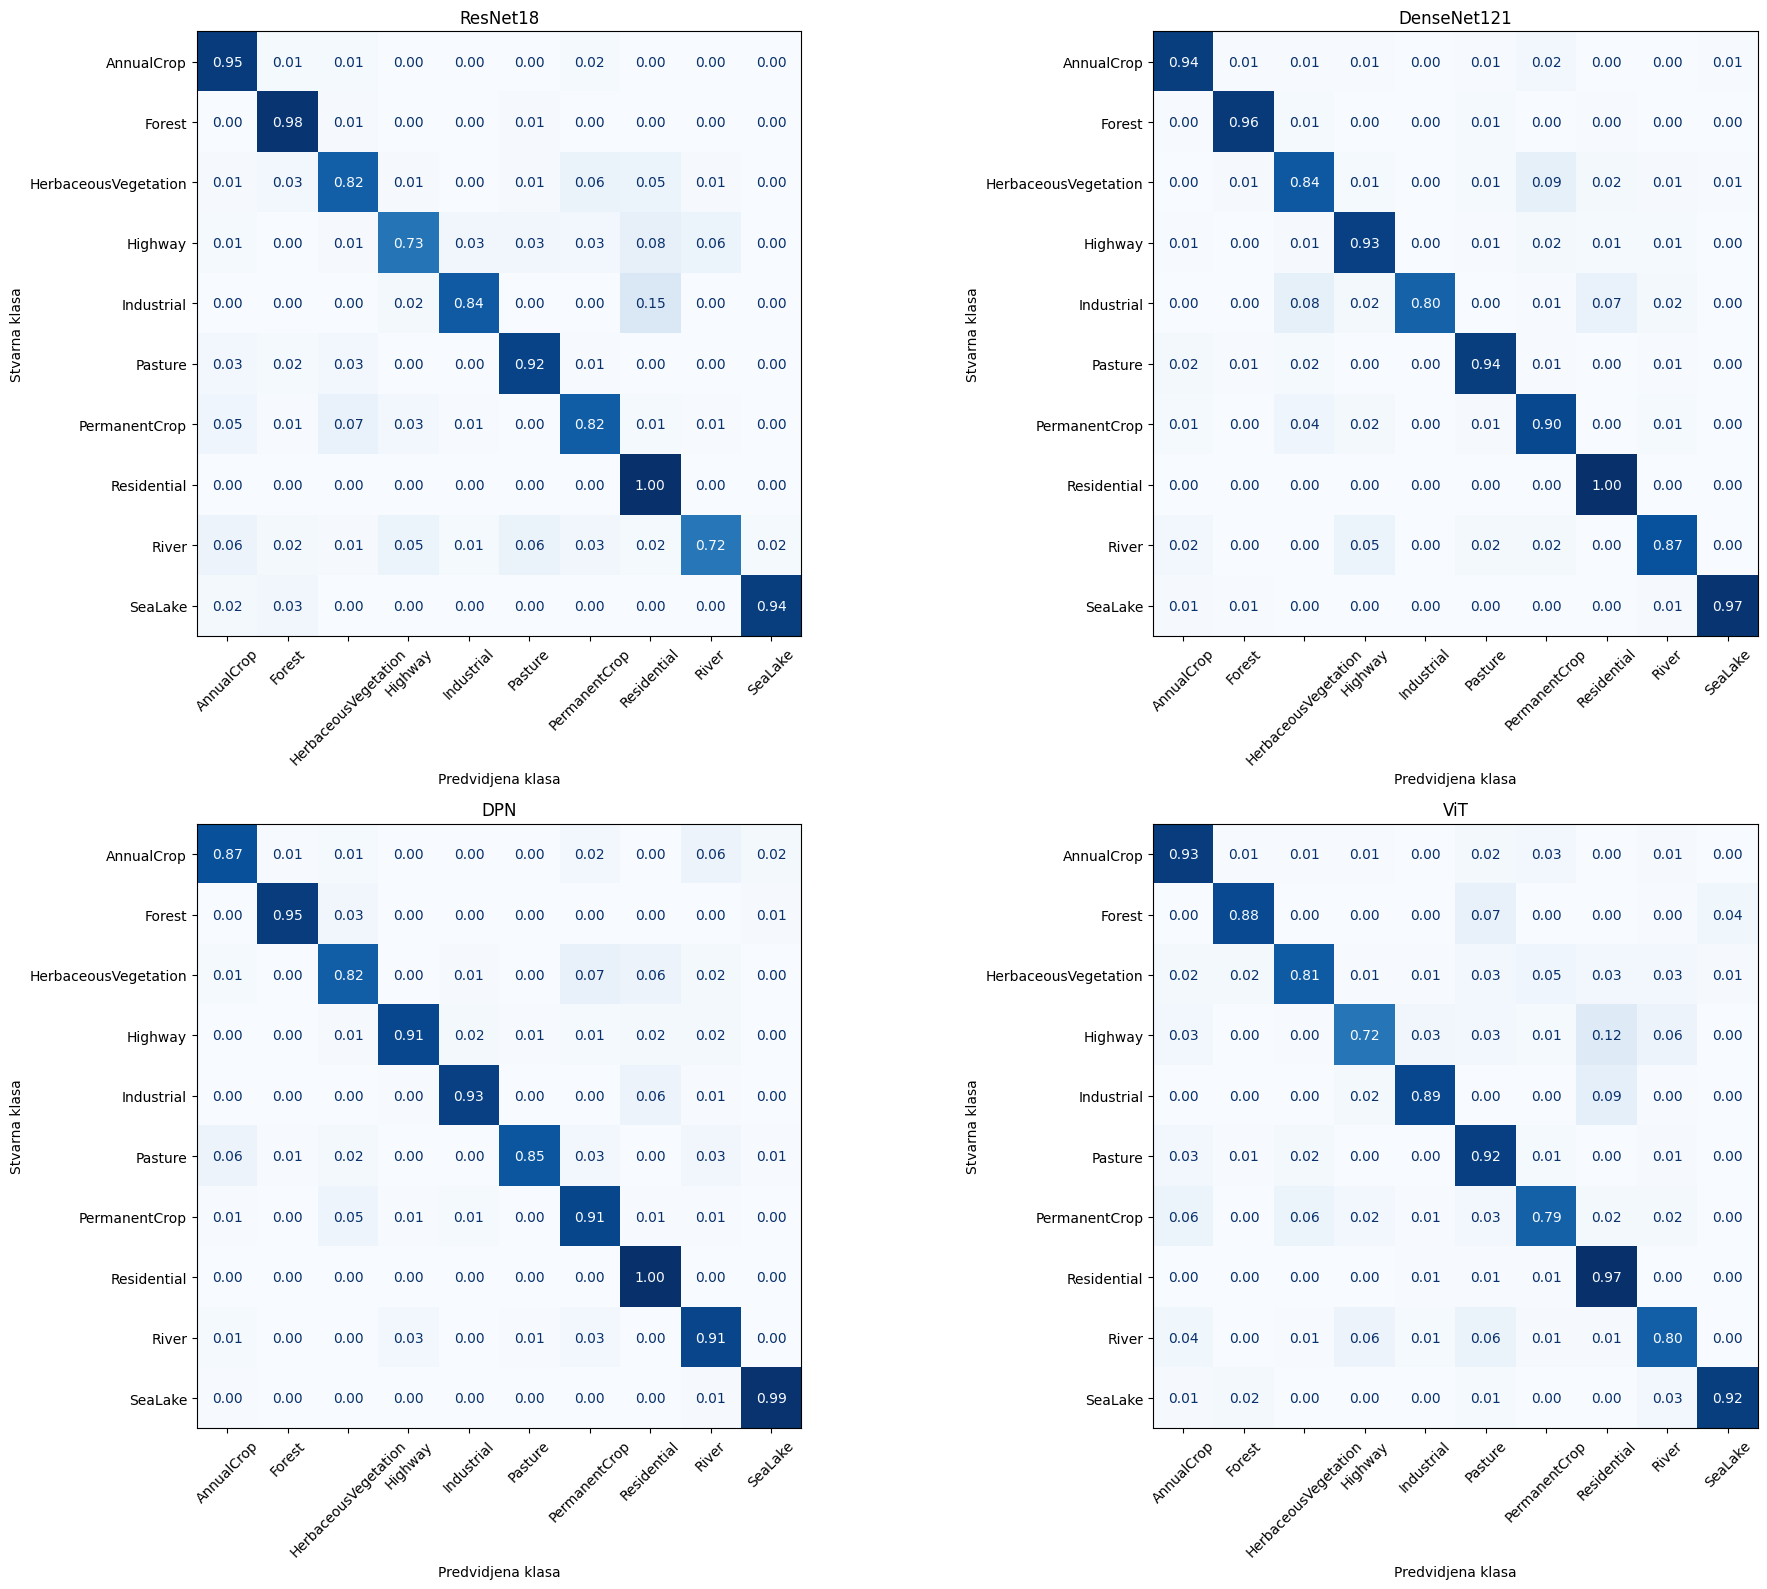

In [ ]:
models_for_evaluation = [
    ("ResNet18", ResNet18(), "resnet18.pth"),
    ("DenseNet121", DenseNet121(), "densenet121.pth"),
    ("DPN", DPN(), "dpn.pth"),
    ("ViT", VisionTransformer(), "vit.pth")
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 16)
)

all_predictions = {}

for axis, model_data in zip(
    axes.flatten(),
    models_for_evaluation
):

    model_name, current_model, checkpoint_name = model_data

    true_labels, predicted_labels = get_predictions(
        current_model,
        checkpoint_name
    )

    all_predictions[model_name] = (
        true_labels,
        predicted_labels
    )

    ConfusionMatrixDisplay.from_predictions(
        true_labels,
        predicted_labels,
        display_labels=dataset.classes,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45,
        ax=axis
    )

    axis.set_title(model_name)
    axis.set_xlabel("Predvidjena klasa")
    axis.set_ylabel("Stvarna klasa")

plt.tight_layout()

plt.savefig(
    figures_path / "confusion_matrices.png",
    dpi=200
)

plt.show()

# DPN i ViT classification report

In [ ]:
from sklearn.metrics import classification_report


# DPN rezultati

dpn_true, dpn_predicted = all_predictions["DPN"]

dpn_report = classification_report(
    dpn_true,
    dpn_predicted,
    target_names=dataset.classes,
    digits=3
)

print("DPN")
print(dpn_report)


# ViT rezultati

vit_true, vit_predicted = all_predictions["ViT"]

vit_report = classification_report(
    vit_true,
    vit_predicted,
    target_names=dataset.classes,
    digits=3
)

print("ViT")
print(vit_report)


# Cuvanje rezultata

reports_path = project_path / "results" / "metrics"

with open(
    reports_path / "dpn_classification_report.txt",
    "w"
) as file:

    file.write(dpn_report)


with open(
    reports_path / "vit_classification_report.txt",
    "w"
) as file:

    file.write(vit_report)

DPN
                      precision    recall  f1-score   support

          AnnualCrop      0.920     0.874     0.897       596
              Forest      0.990     0.949     0.969       608
HerbaceousVegetation      0.872     0.822     0.846       573
             Highway      0.949     0.907     0.928       496
          Industrial      0.949     0.932     0.941       501
             Pasture      0.971     0.854     0.909       396
       PermanentCrop      0.849     0.911     0.879       538
         Residential      0.878     0.998     0.934       554
               River      0.856     0.913     0.884       529
             SeaLake      0.958     0.985     0.972       609

            accuracy                          0.917      5400
           macro avg      0.919     0.915     0.916      5400
        weighted avg      0.919     0.917     0.917      5400

ViT
                      precision    recall  f1-score   support

          AnnualCrop      0.852     0.926     0.887       

# Vizuelni prikaz primera sa istaknutim klasama i outputs DPN-a

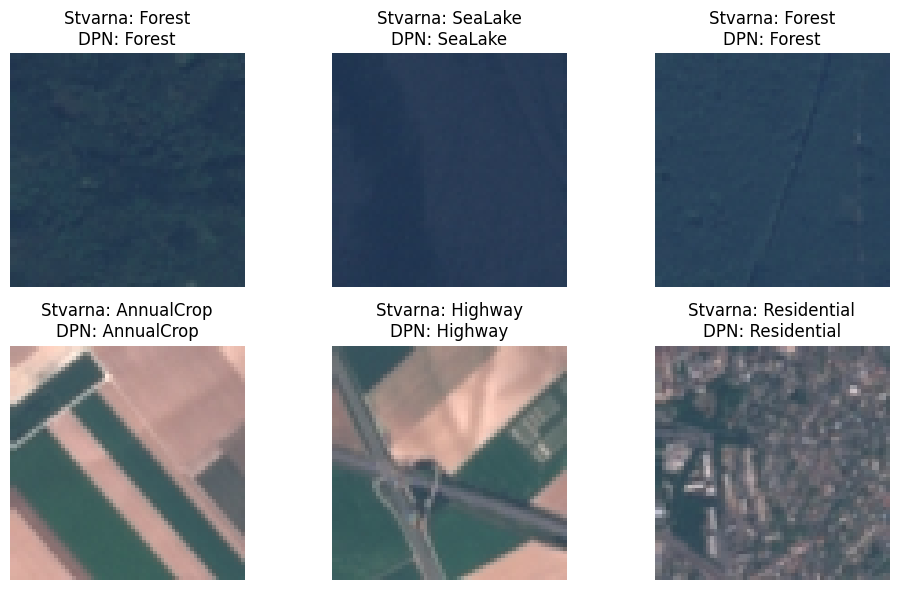

In [ ]:
plt.figure(figsize=(10, 6))

for index in range(6):

    image, true_label = test_data[index]
    predicted_label = dpn_predicted[index]

    # Ponistavanje normalizacije

    image = image * 0.5 + 0.5

    plt.subplot(2, 3, index + 1)

    plt.imshow(
        image.permute(1, 2, 0)
    )

    plt.title(
        f"Stvarna: {dataset.classes[true_label]}\n"
        f"DPN: {dataset.classes[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()

example_path = (
    figures_path / "dpn_prediction_examples.png"
)

plt.savefig(
    example_path,
    dpi=200
)

plt.show()

In [ ]:
import pandas as pd


comparison_table = pd.DataFrame({

    "Model": [
        "ResNet18",
        "DenseNet121",
        "DPN",
        "ViT"
    ],

    "Broj parametara": [
        sum(p.numel() for p in ResNet18().parameters()),
        sum(p.numel() for p in DenseNet121().parameters()),
        sum(p.numel() for p in DPN().parameters()),
        sum(
            p.numel()
            for p in VisionTransformer().parameters()
        )
    ],

    "Najbolja epoha": [
        resnet_val_accuracy.index(
            max(resnet_val_accuracy)
        ) + 1,

        densenet_val_accuracy.index(
            max(densenet_val_accuracy)
        ) + 1,

        dpn_val_accuracy.index(
            max(dpn_val_accuracy)
        ) + 1,

        vit_val_accuracy.index(
            max(vit_val_accuracy)
        ) + 1
    ],

    "Validaciona tacnost": [
        round(max(resnet_val_accuracy), 2),
        round(max(densenet_val_accuracy), 2),
        round(max(dpn_val_accuracy), 2),
        round(max(vit_val_accuracy), 2)
    ],

    "Test tacnost": [
        round(resnet_test_accuracy, 2),
        round(densenet_test_accuracy, 2),
        round(dpn_test_accuracy, 2),
        round(vit_test_accuracy, 2)
    ]
})

display(comparison_table)


comparison_file = (
    project_path
    / "results"
    / "metrics"
    / "model_comparison.csv"
)

comparison_table.to_csv(
    comparison_file,
    index=False
)


,Model,Broj parametara,Najbolja epoha,Validaciona tacnost,Test tacnost
0,ResNet18,11173962,6,87.04,87.56
1,DenseNet121,6956426,8,91.44,91.81
2,DPN,9778522,10,90.81,91.67
3,ViT,299658,10,86.20,86.37
